# 💳 Détection de Fraude Bancaire avec Machine Learning

## 🎯 Objectif
Ce projet vise à détecter les transactions frauduleuses dans un système bancaire en utilisant des techniques de Machine Learning.  
Le défi principal est le déséquilibre des classes (fraude très rare).

## 📊 Dataset
- Source : Kaggle – Credit Card Fraud Detection  
- Nombre de transactions : 284 807  
- Fraudes : 492 (~0.17%)

## ⚙️ Méthodologie
1. Analyse exploratoire des données (EDA)
2. Prétraitement et gestion du déséquilibre (SMOTE)
3. Entraînement de modèles :
   - Logistic Regression
   - Random Forest
   - XGBoost
4. Évaluation avec :
   - F1-Score
   - AUC-ROC
   - Recall (prioritaire)

##  Objectif final
Identifier le meilleur modèle pour détecter efficacement les fraudes tout en minimisant les faux négatifs.

# ***1 - Import des bibliothèques***

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler      # Pour normaliser
from sklearn.model_selection import train_test_split  # Pour diviser train/test
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [29]:
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv.zip', compression='zip')
print(f"   Nombre de lignes    : {len(df)}")
print(f"   Nombre de colonnes  : {len(df.columns)}")
df.head()

   Nombre de lignes    : 284807
   Nombre de colonnes  : 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [31]:
compter = df['Class'].value_counts()

print("Nombre de transactions LÉGITIMES :", compter[0])
print("Nombre de transactions FRAUDES   :", compter[1])

print("Pourcentage de fraudes :", round(compter[1] / len(df) * 100, 2), "%")


Nombre de transactions LÉGITIMES : 284315
Nombre de transactions FRAUDES   : 492
Pourcentage de fraudes : 0.17 %


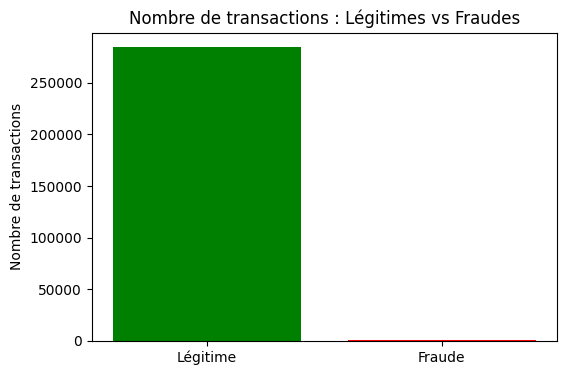

In [32]:
plt.figure(figsize=(6, 4))

plt.bar(
    ['Légitime', 'Fraude'],      # Noms des barres
    [compter[0], compter[1]],    # Valeurs
    color=['green', 'red']       # Couleurs
)

plt.title('Nombre de transactions : Légitimes vs Fraudes')
plt.ylabel('Nombre de transactions')
plt.show()

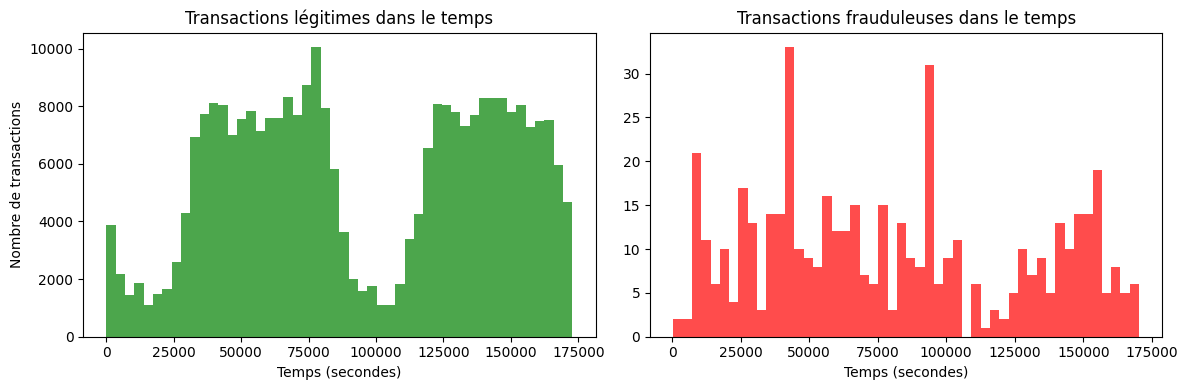

Observation : Les fraudes sont réparties de façon plus uniforme dans le temps.


In [33]:
# La colonne 'Time' = secondes depuis la 1ère transaction
# On regarde si les fraudes arrivent à des moments particuliers
legitimes = df[df['Class'] == 0]
fraudes = df[df['Class'] == 1]
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(legitimes['Time'], bins=50, color='green', alpha=0.7)
plt.title('Transactions légitimes dans le temps')
plt.xlabel('Temps (secondes)')
plt.ylabel('Nombre de transactions')

plt.subplot(1, 2, 2)
plt.hist(fraudes['Time'], bins=50, color='red', alpha=0.7)
plt.title('Transactions frauduleuses dans le temps')
plt.xlabel('Temps (secondes)')

plt.tight_layout()
plt.show()

print("Observation : Les fraudes sont réparties de façon plus uniforme dans le temps.")

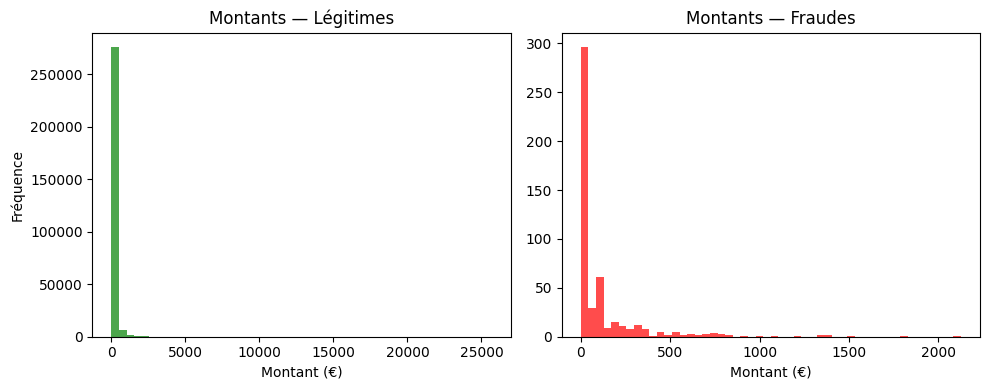

Les fraudeurs évitent les gros montants pour ne pas déclencher les alertes bancaires. 


In [ ]:
Légitimes = df[df['Class'] == 0]
fraudes = df[df['Class'] == 1]

plt.figure(figsize=(10, 4))

# Graphique 1 : montants légitimes
plt.subplot(1, 2, 1)   # 1 ligne, 2 colonnes, graphique n°1
plt.hist(Légitimes['Amount'], bins=50, color='green', alpha=0.7)
plt.title('Montants — Légitimes')
plt.xlabel('Montant (€)')
plt.ylabel('Fréquence')

# Graphique 2 : montants fraudes
plt.subplot(1, 2, 2)   # 1 ligne, 2 colonnes, graphique n°2
plt.hist(fraudes['Amount'], bins=50, color='red', alpha=0.7)
plt.title('Montants — Fraudes')
plt.xlabel('Montant (€)')

plt.tight_layout()     # Pour que les graphiques ne se chevauchent pas
plt.show()

print("Les fraudeurs évitent les gros montants pour ne pas déclencher les alertes bancaires. ")

In [ ]:
valeurs_manquantes = df.isnull().sum().sum()

if valeurs_manquantes == 0:
    print(" Aucune valeur manquante dans le dataset.")
else:
    print(f" Il y a {valeurs_manquantes} valeurs manquantes à traiter.")


 Aucune valeur manquante dans le dataset.


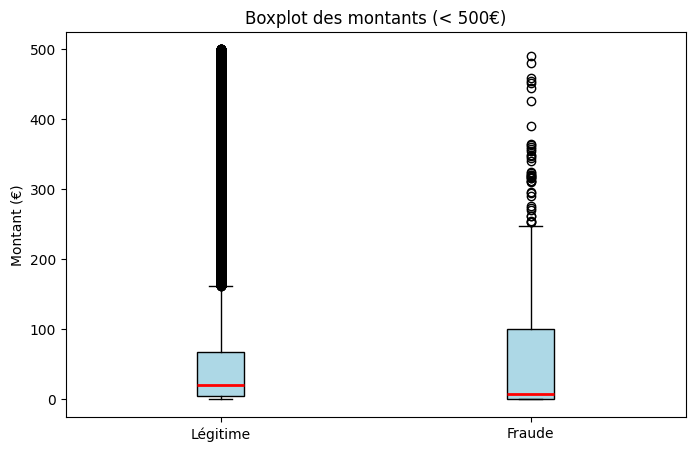

 Observation : Les fraudes ont souvent des montants plus petits et groupés.


In [41]:
plt.figure(figsize=(8, 5))

# On limite à 5000 pour mieux voir (il y a des valeurs très grandes)
data_boxplot = [
    legitimes[legitimes['Amount'] < 500]['Amount'],
    fraudes[fraudes['Amount'] < 500]['Amount']
]

plt.boxplot(data_boxplot, tick_labels=['Légitime', 'Fraude'], patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Boxplot des montants (< 500€)')
plt.ylabel('Montant (€)')
plt.show()

print(" Observation : Les fraudes ont souvent des montants plus petits et groupés.")

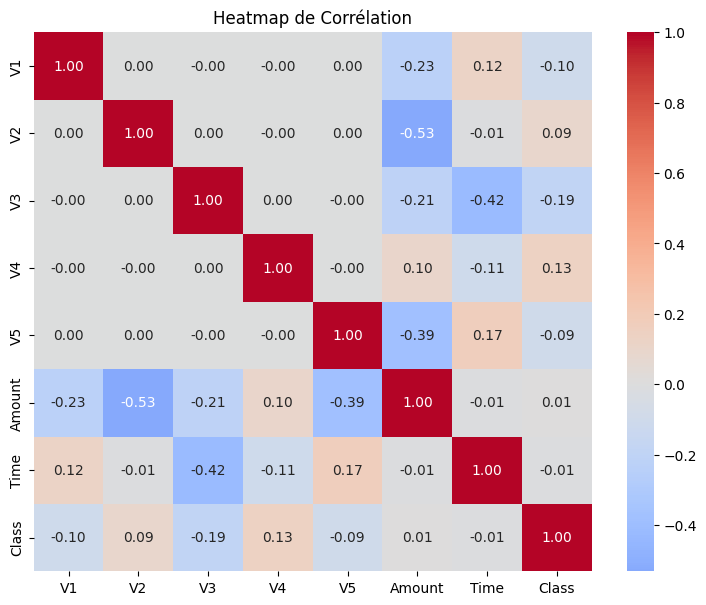

 Observation : V1, V2, V3... ont des corrélations avec 'Class' (notre cible).


In [ ]:
# On prend seulement quelques colonnes pour que ce soit lisible
colonnes_heatmap = ['V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Time', 'Class']

correlation = df[colonnes_heatmap].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation,
    annot=True,       # Afficher les valeurs dans les cases
    fmt='.2f',        # 2 décimales
    cmap='coolwarm',  # Couleurs : bleu (négatif) → rouge (positif)
    center=0
)
plt.title('Heatmap de Corrélation')
plt.show()

print(" Observation : V1, V2, V3... ont des corrélations avec 'Class' (notre cible).")

In [ ]:
# On cherche quelles colonnes sont les plus corrélées avec 'Class'
correlation_avec_fraude = df.corr()['Class'].drop('Class')

# Trier du plus corrélé au moins corrélé (en valeur absolue)
correlation_triee = correlation_avec_fraude.abs().sort_values(ascending=False)

print("🔍 Top 10 des variables les plus liées à la fraude :\n")
print(correlation_triee.head(10).round(4))






🔍 Top 10 des variables les plus liées à la fraude :

V17    0.3265
V14    0.3025
V12    0.2606
V10    0.2169
V16    0.1965
V3     0.1930
V7     0.1873
V11    0.1549
V4     0.1334
V18    0.1115
Name: Class, dtype: float64


In [ ]:
df2 = df.copy()

scaler = StandardScaler()

# Normaliser Amount et Time (les mettre sur la même échelle que V1-V28)
df2['Amount'] = scaler.fit_transform(df2['Amount'].values.reshape(-1, 1))
df2['Time']   = scaler.fit_transform(df2['Time'].values.reshape(-1, 1))

print("Normalisation effectuée !")
print(f"Amount avant : min={df['Amount'].min():.0f}€  max={df['Amount'].max():.0f}€")
print(f"Amount après : min={df2['Amount'].min():.2f}€  max={df2['Amount'].max():.2f}€")


Normalisation effectuée !
Amount avant : min=0€  max=25691€
Amount après : min=-0.35€  max=102.36€


In [ ]:
df2_cleaned = df2.dropna(subset=['Class'])

X = df2_cleaned.drop('Class', axis=1)   # axis=1 = supprimer une colonne
y = df2_cleaned['Class']

print(f" X (variables d'entrée) : {X.shape}")   # (284807, 30)
print(f" y (cible à prédire)    : {y.shape}")   # (284807,)
print(f"\n   Fraudes dans y : {y.sum()} ({y.mean()*100:.2f}%)")

 X (variables d'entrée) : (284807, 30)
 y (cible à prédire)    : (284807,)

   Fraudes dans y : 492 (0.17%)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test
    random_state=42,    # Pour avoir les mêmes résultats à chaque exécution
    stratify=y          # Garder le même % de fraudes dans train et test
)

print(f"Split effectué !")
print(f"   Train : {X_train.shape[0]:,} lignes  ({y_train.sum()} fraudes)")
print(f"   Test  : {X_test.shape[0]:,} lignes  ({y_test.sum()} fraudes)")

Split effectué !
   Train : 227,845 lignes  (394 fraudes)
   Test  : 56,962 lignes  (98 fraudes)


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f" SMOTE appliqué ")
print(f"\n   AVANT SMOTE :")
print(f"   Légitimes : {(y_train == 0).sum():,}  |  Fraudes : {(y_train == 1).sum():,}")
print(f"\n   APRÈS SMOTE :")
print(f"   Légitimes : {(y_train_smote == 0).sum():,}  |  Fraudes : {(y_train_smote == 1).sum():,}")



 SMOTE appliqué 

   AVANT SMOTE :
   Légitimes : 227,451  |  Fraudes : 394

   APRÈS SMOTE :
   Légitimes : 227,451  |  Fraudes : 227,451


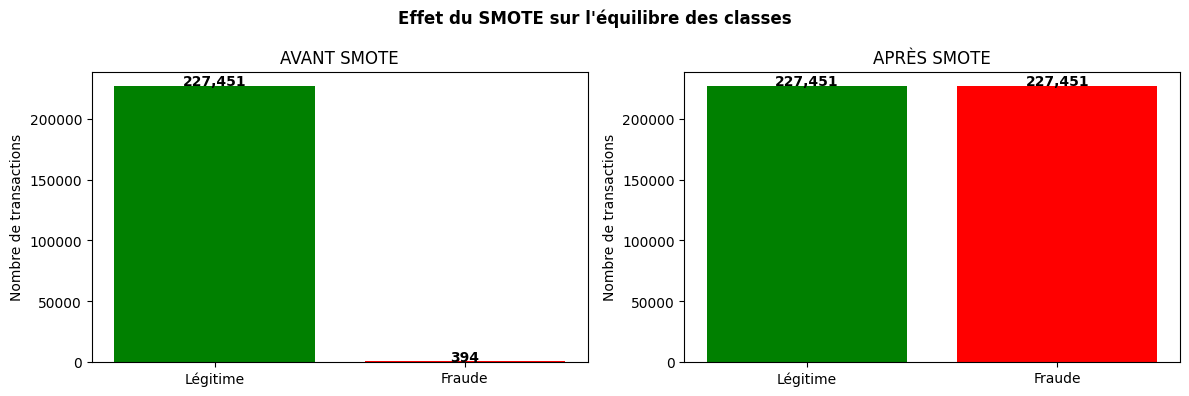

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Avant SMOTE
avant = pd.Series(y_train).value_counts()
axes[0].bar(['Légitime', 'Fraude'], avant.values, color=['green', 'red'])
axes[0].set_title('AVANT SMOTE')
axes[0].set_ylabel('Nombre de transactions')
for i, v in enumerate(avant.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Après SMOTE
apres = pd.Series(y_train_smote).value_counts()
axes[1].bar(['Légitime', 'Fraude'], apres.values, color=['green', 'red'])
axes[1].set_title('APRÈS SMOTE')
axes[1].set_ylabel('Nombre de transactions')
for i, v in enumerate(apres.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Effet du SMOTE sur l\'équilibre des classes', fontweight='bold')
plt.tight_layout()
plt.show()



In [ ]:
import pickle

# On sauvegarde tout dans un fichier pour réutiliser
data = {
    'X_train': X_train_smote,
    'X_test' : X_test,
    'y_train': y_train_smote,
    'y_test' : y_test
}

with open('donnees_preparees.pkl', 'wb') as f:
    pickle.dump(data, f)


In [ ]:
# Charger les données préparées
with open('donnees_preparees.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

print(" Données chargées !")
print(f"   Train : {X_train.shape[0]:,} lignes  |  Test : {X_test.shape[0]:,} lignes")

 Données chargées !
   Train : 454,902 lignes  |  Test : 56,962 lignes


In [ ]:
print("Entraînement Logistic Regression:")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)          #  Le modèle apprend ici
y_pred_lr = lr.predict(X_test)    #  Le modèle prédit sur les données de test

print(" Logistic Regression terminée !")
print("\n Résultats :")
print(classification_report(y_test, y_pred_lr, target_names=['Légitime', 'Fraude']))

f1_lr  = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print(f"   F1-Score : {f1_lr:.4f}  |  AUC-ROC : {auc_lr:.4f}")

### 🔍 Observation — Logistic Regression
Le F1-Score très bas (0.109) s'explique par la nature linéaire du modèle :
malgré le SMOTE, la Logistic Regression peine à capturer les patterns
non-linéaires complexes des fraudes. Elle sert ici de **baseline de référence**.

In [27]:
print(" Entraînement Random Forest:")

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(" Random Forest terminé !")
print("\n Résultats :")
print(classification_report(y_test, y_pred_rf, target_names=['Légitime', 'Fraude']))

f1_rf  = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print(f"   F1-Score : {f1_rf:.4f}  |  AUC-ROC : {auc_rf:.4f}")

 Entraînement Random Forest:
 Random Forest terminé !

 Résultats :
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

   F1-Score : 0.8410  |  AUC-ROC : 0.9731


In [34]:

print(" Entraînement XGBoost:")

xgb = XGBClassifier(n_estimators=100, random_state=42,
                    use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(" XGBoost terminé !")
print("\n Résultats :")
print(classification_report(y_test, y_pred_xgb, target_names=['Légitime', 'Fraude']))

f1_xgb  = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print(f"   F1-Score : {f1_xgb:.4f}  |  AUC-ROC : {auc_xgb:.4f}")

 Entraînement XGBoost:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:10:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost terminé !

 Résultats :
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962

   F1-Score : 0.8018  |  AUC-ROC : 0.9792



 COMPARAISON DES MODÈLES :
             Modèle  F1-Score  AUC-ROC
Logistic Regression  0.109356 0.969848
      Random Forest  0.841026 0.973103
            XGBoost  0.801843 0.979159


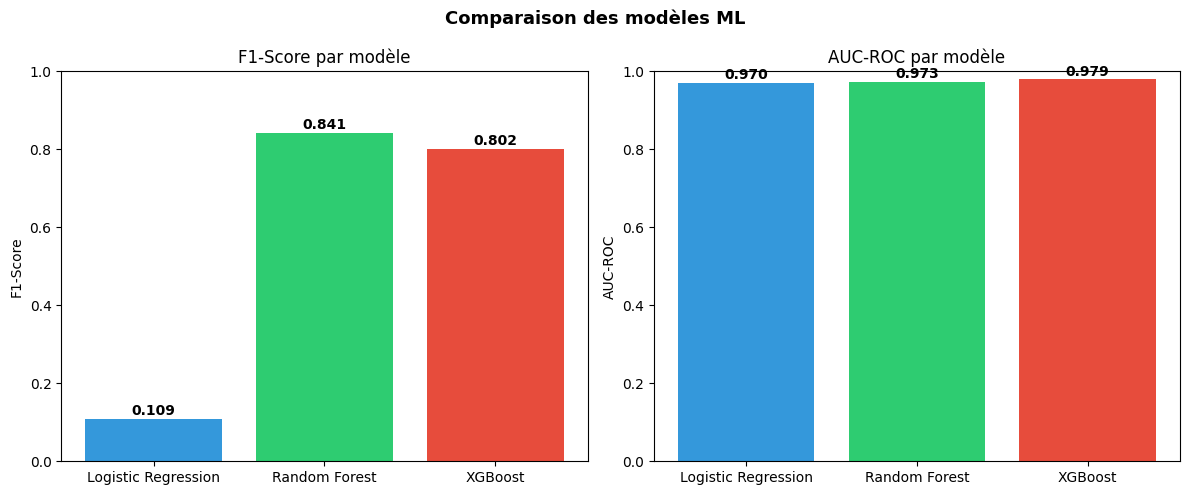

In [35]:

resultats = pd.DataFrame({
    'Modèle'  : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'F1-Score': [f1_lr, f1_rf, f1_xgb],
    'AUC-ROC' : [auc_lr, auc_rf, auc_xgb]
})

print("\n COMPARAISON DES MODÈLES :")
print(resultats.to_string(index=False)) #Convertit le DataFrame en texte lisible pour l'affichage Supprime les numéros de lignes affichage plus propre et professionnel

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']

axes[0].bar(resultats['Modèle'], resultats['F1-Score'], color=colors)
axes[0].set_title('F1-Score par modèle')
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(resultats['F1-Score']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(resultats['Modèle'], resultats['AUC-ROC'], color=colors)
axes[1].set_title('AUC-ROC par modèle')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim(0, 1)
for i, v in enumerate(resultats['AUC-ROC']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Comparaison des modèles ML', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


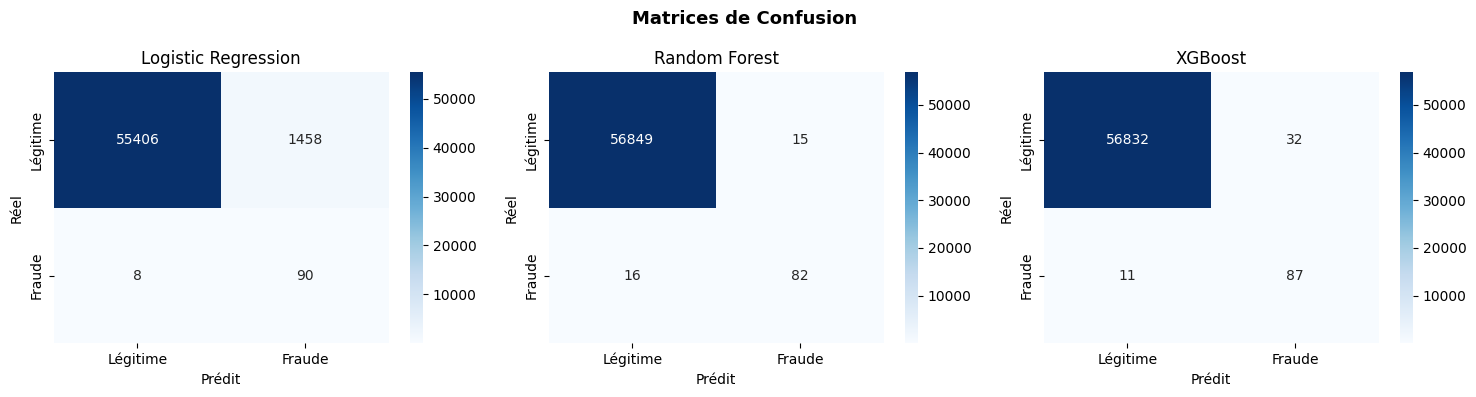

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

modeles     = ['Logistic Regression', 'Random Forest', 'XGBoost']
predictions = [y_pred_lr, y_pred_rf, y_pred_xgb]

for ax, nom, pred in zip(axes, modeles, predictions):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Légitime', 'Fraude'],
                yticklabels=['Légitime', 'Fraude'])
    ax.set_title(nom)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de Confusion', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## **🏁 Conclusion**

## 🏆 Modèle retenu : Random Forest
Le modèle Random Forest donne les meilleurs résultats avec un bon équilibre entre précision et détection des fraudes.

## 💡 Ce que j’ai appris
- L’accuracy n’est pas fiable sur des données déséquilibrées  
- Le recall est essentiel pour ne pas rater les fraudes  
- SMOTE améliore fortement les performances  
- Certaines variables sont plus importantes que d’autres  

## 🚀 Améliorations possibles
- Optimiser les paramètres des modèles  
- Tester d’autres méthodes comme la détection d’anomalies  
- Déployer le modèle en API  
- Ajuster le seuil pour améliorer le recall  

## 🎯 Conclusion générale
Une bonne gestion du déséquilibre et le choix des bonnes métriques sont essentiels pour détecter efficacement les fraudes.